# Messy Sales Data Cleaning & Exploratory Analysis
 
 This Project focuses on cleaning a messy sales dataset and performing exploratory data analysis using Python.
 Objectives:
 
    Handle Missing Values
    Remove Duplicate Values
    Fix inconsistent data formats
    Generate Business insights from cleaned data

In [ ]:
# Import Libraris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

#Load Dataset
df = pd.read_csv("../dataset/messy_sales_data.csv")

#Display first 5 rows
print(df.head())

   Unnamed: 0  transaction_id customer_name product price  quantity  \
0           0               1           bob     Tea    10       1.0   
1           1               2       michael  Coffee   7.5       1.0   
2           2               3       michael   Juice    9        4.0   
3           3               4    Jane Smith   Juice    12       NaN   
4           4               5    Jane Smith  Coffee   7.5       4.0   

         date payment_method     location  
0  2023-05-13            NaN  Los Angeles  
1  2023-05-16          Card       Houston  
2         NaN           Cash        Miami  
3         NaN            NaN      Houston  
4         NaN            NaN      Houston  


# Dataset Overview

In [2]:
#Check dataset structure
df.info()
#Summary Statistics
df.describe()
#Check Missing Values
df.isnull().sum()
#Identify Duplicates & Remove them
duplicate = df.duplicated()
print('\nDuplicate Values', duplicate)
df.drop_duplicates()
print('\nDuplicate Values Now', duplicate)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10200 non-null  int64  
 1   transaction_id  10200 non-null  int64  
 2   customer_name   8482 non-null   object 
 3   product         10200 non-null  object 
 4   price           8795 non-null   object 
 5   quantity        8190 non-null   float64
 6   date            3399 non-null   object 
 7   payment_method  8537 non-null   object 
 8   location        10200 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 717.3+ KB

Duplicate Values 0        False
1        False
2        False
3        False
4        False
         ...  
10195    False
10196    False
10197    False
10198    False
10199    False
Length: 10200, dtype: bool

Duplicate Values Now 0        False
1        False
2        False
3        False
4        False
         ...  
10195    Fa

# Data Cleaning

In [3]:
#Remove Duplicates
df.drop_duplicates()
#Convert into Numeric
df['price'] = pd.to_numeric(df['price'], errors= "coerce")
#Handle Missing Values
df['price'] = df['price'].fillna(df['price'].median())
#Assuming 1 as missing quantities
df['quantity'] = df['quantity'].fillna(1)
#Assuming missing customers as Unknown
df['customer_name'] = df['customer_name'].fillna('Unknown')
#Using mode to fill payment_method's missing rows
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])
#Clean text columns
df['customer_name'] = df['customer_name'].str.strip().str.title()
#Convert date format and replace missing rows with random realistic date 
df['date'] = pd.to_datetime(df['date'], errors="coerce")
random_dates =  pd.date_range(start="2023-01-01", end= "2023-12-31")
missing_dates = df['date'].isna()
df.loc[missing_dates, 'date'] = np.random.choice(random_dates, missing_dates.sum())

# Save Cleaned Dataset

In [ ]:
df.to_csv("../dataset/cleaned_sales_data_v1.csv", index= False)

# Feature Engineering

In [5]:
#Create Revenue Column
df['revenue'] = df['price'] * df['quantity']

# Exploratory Data Analysis

In [6]:
#Find top selling products
top_products = df.groupby('product')['revenue'].sum().sort_values(ascending=False)

top_products.head()

product
Cookie      34185.5
Cake        33843.0
Tea         33151.0
Sandwich    33073.0
Coffee      32201.5
Name: revenue, dtype: float64

In [7]:
#Revenue by location
#Analyze revenue generated by different locations
location_revenue = df.groupby('location')['price'].sum().sort_values(ascending=False)

location_revenue

location
Los Angeles    18165.5
Miami          18117.0
New York       18094.0
Houston        17873.0
Chicago        17493.5
Name: price, dtype: float64

# Visualization

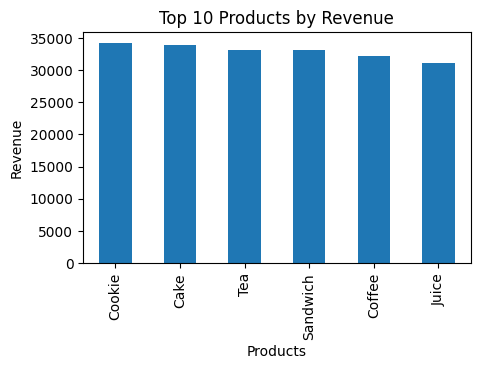

In [8]:
plt.figure(figsize=(5,3))
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xticks = True
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.show()

# Top Products by Revenue Insight 
Bakery Products like cookies and cake generate the highest revenue 
indicating strong customer demand for bakery items compared to beverages.

Business Impact-
Bakery Products are main contributors of overall revenue. If company focuses
on promoting these high-demanding-products, it can increase the total sales
and average order value.

Recommended Action-
Company should promote the bakery products through combo offers like 
coffee + cookies or cake + beverages deals results in increase sales.

# Revenue by Location Insight
Los Angeles generate the highest revenue among locations 
while Chicago has shows comparatively lower revenue.

Business Impact-
Los Angeles and Miami are generating high revenue while lower performing 
locations like chicago may be missing potential revenue opportunity
lead to impact on overall business growth if stores consistently underperform.

Recommended Action-
Company should analyze the customer's preferences in lower performing 
locations and introduce targeted discount and promotions. promoting high-selling
products like bakery items and customer's demanded items can help in increase 
sales in lower performing locations. 

 

# Overall Conclusion
The analysis shows that bakery products contribute the most to revenue, and location-based
performance varies across cities. Focusing on high-demand products and improving 
low-performing store locations can help to increase overall business revenue.